# Stage B validation — RF vs kriging head-to-head

Side-by-side comparison of the two gap-fill candidates against AERONET.

Two flavours of comparison:
1. **Side-by-side panels** — independent metric panels for each candidate.
2. **Paired skill** — restricts to *identical* `(slot, site)` keys present in both candidates, then runs a paired t-test on `|error|`.  Avoids the trap where one candidate is graded on easier days than the other.

In [1]:
from datetime import date
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import validate as vb
import config as cfg

START = cfg.TEST_START
END   = cfg.TEST_END
print(f'Held-out window: {START} → {END}')

Held-out window: 2025-01-01 → 2026-04-30


## Extract blind pairs for both candidates

In [2]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='rf',      blind_only=True)
pairs_kr = vb.aeronet_pairs(START, END, candidate='kriging', blind_only=True)
print(f'AERONET-blind pairs — RF: {len(pairs_rf)}, kriging: {len(pairs_kr)}')

AERONET-blind pairs — RF: 636, kriging: 631


## Side-by-side metric panels

`compare_candidates` returns each candidate's full panel plus a `SUMMARY` row with the mean RMSE across `(site, season)` cells.

In [3]:
vb.compare_candidates({'rf': pairs_rf, 'kriging': pairs_kr})

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,site,season,candidate
0,422.0,-0.045149,-2.445937,0.262278,0.216074,0.166438,24.170616,site=Bac_Lieu,Bac_Lieu,all,rf
1,214.0,0.719599,0.458729,0.555992,0.320579,-0.074520,37.383178,site=NGHIA_DO,NGHIA_DO,all,rf
2,229.0,0.235561,-0.152583,0.176566,0.139156,0.049273,41.048035,site=Bac_Lieu season=dry,Bac_Lieu,dry,rf
3,193.0,0.300802,-33.103724,0.336779,0.307340,0.305456,4.145078,site=Bac_Lieu season=wet,Bac_Lieu,wet,rf
4,122.0,0.719204,0.409731,0.686266,0.410781,-0.189310,36.065574,site=NGHIA_DO season=dry,NGHIA_DO,dry,rf
5,92.0,0.212664,-0.286903,0.307443,0.200963,0.077700,39.130435,site=NGHIA_DO season=wet,NGHIA_DO,wet,rf
6,636.0,0.691661,0.426528,0.386856,0.251238,0.085361,28.616352,ALL,ALL,all,rf
7,417.0,0.236163,-0.535405,0.175589,0.132992,0.070672,39.328537,site=Bac_Lieu,Bac_Lieu,all,kriging
8,214.0,0.855045,0.718569,0.400910,0.261310,-0.012910,35.514019,site=NGHIA_DO,NGHIA_DO,all,kriging
9,224.0,0.465351,0.209592,0.146340,0.110106,-0.002046,52.678571,site=Bac_Lieu season=dry,Bac_Lieu,dry,kriging


## Paired skill — identical `(slot, site)` keys

Reports paired RMSE difference (`rmse_a − rmse_b` = `rf − kriging`) and the paired t-test on absolute errors.  `p_value < 0.05` means the candidates differ significantly on the shared key set.

In [4]:
vb.paired_skill(pairs_rf, pairs_kr)

{'n_paired': 631,
 'rmse_a': 0.3873842929223368,
 'rmse_b': 0.2736519636743108,
 'rmse_diff_a_minus_b': 0.11373232924802595,
 't_statistic': 8.790784205789596,
 'p_value': 1.4087376929695343e-17}

## Scatter — RF vs kriging vs AERONET

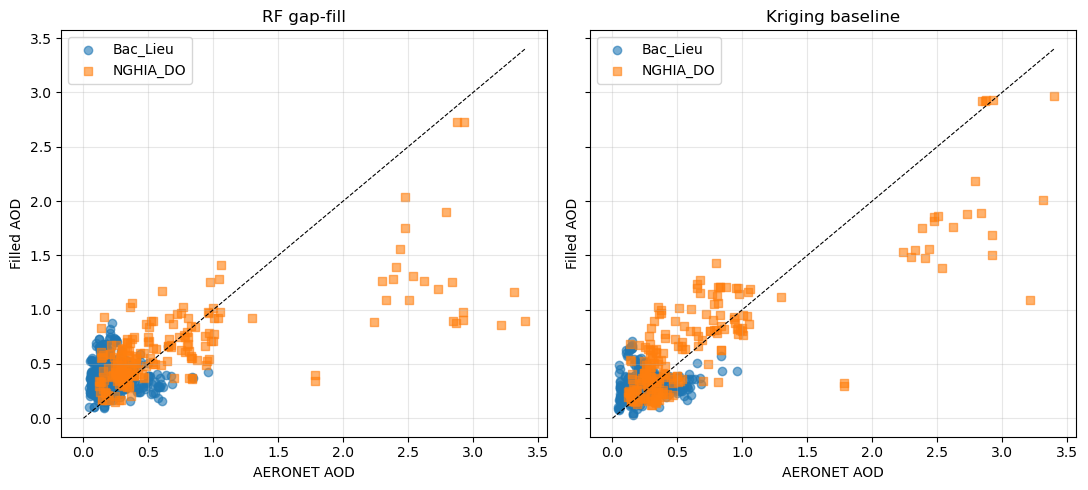

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, (label, df) in zip(axes, [('RF gap-fill', pairs_rf), ('Kriging baseline', pairs_kr)]):
    if df.empty:
        ax.set_title(f'{label}: no matched pairs'); ax.set_visible(False); continue
    for site, marker in zip(df['site'].unique(), ('o', 's', '^', 'D')):
        sub = df[df['site'] == site]
        ax.scatter(sub['aer_aod'], sub['sat_aod'], alpha=0.6, label=site, marker=marker)
    lim = max(df[['aer_aod', 'sat_aod']].max().max(), 1.0)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('Filled AOD'); ax.set_title(label)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()